In [ ]:
# 1.
import pandas as pd
from company_name_matcher import CompanyNameMatcher
import os
import wrds

In [ ]:
# --- 第2步：定义文件路径和加载数据 ---
phase1_output_file = 'firm_monthly_panel_data_revised.csv'
wrds_company_list_file = 'wrds_companies.csv'
mapping_output_file = 'glassdoor_to_wrds_mapping.csv'

print(f"--- 正在加载数据... ---")
try:
    df_glassdoor = pd.read_csv(phase1_output_file)
    print(f"成功加载Glassdoor数据: '{phase1_output_file}'")
except FileNotFoundError:
    print(f"错误：找不到文件 '{phase1_output_file}'。请确保您已成功运行第一阶段的代码。")
    exit()

try:
    df_wrds = pd.read_csv(wrds_company_list_file)
    if 'gvkey' not in df_wrds.columns or 'conm' not in df_wrds.columns:
        print(f"错误：'{wrds_company_list_file}' 文件中必须包含 'gvkey' 和 'conm' 列。")
        exit()
    print(f"成功加载WRDS公司列表: '{wrds_company_list_file}'")
except FileNotFoundError:
    print(f"错误：找不到标准公司列表文件 '{wrds_company_list_file}'。")
    print("请从WRDS Compustat数据库下载该文件，并确保它包含 'gvkey' 和 'conm' 两列。")
    exit()

print("\n")


# --- 第3步：准备用于匹配的公司列表 ---

print("--- 第3步：准备唯一的公司列表用于匹配... ---")
df_glassdoor_unique = df_glassdoor[['company_code', 'company_name']].dropna(subset=['company_name']).drop_duplicates().reset_index(drop=True)
companies_to_find_matches = df_glassdoor_unique['company_name'].tolist()
companies_to_build_index = df_wrds['conm'].dropna().unique().tolist()

print(f"需要匹配的有效Glassdoor公司数量: {len(companies_to_find_matches)}")
print(f"用于构建索引的WRDS公司数量: {len(companies_to_build_index)}")
print("\n")


# --- 第4步：初始化匹配器并构建/加载索引 ---
print("--- 第4步：初始化匹配器并构建/加载索引... ---")
index_save_dir = "wrds_company_index"

matcher = CompanyNameMatcher("paraphrase-multilingual-MiniLM-L12-v2")

if not os.path.exists(index_save_dir):
    print(f"未找到已保存的索引。正在为 {len(companies_to_build_index)} 家公司构建新索引...")
    
    matcher.build_index(
        companies_to_build_index,
        n_clusters=50,
        save_dir=index_save_dir
    )
    print(f"索引构建完成并已保存到 '{index_save_dir}' 文件夹。")
else:
    print(f"在 '{index_save_dir}' 中找到已存在的索引，正在加载...")
    matcher.load_index(load_dir=index_save_dir)
    print("索引加载完成。")

print("\n")


--- 正在加载数据... ---
成功加载Glassdoor数据: 'firm_monthly_panel_data_revised.csv'
成功加载WRDS公司列表: 'wrds_companies.csv'


--- 第3步：准备唯一的公司列表用于匹配... ---
需要匹配的有效Glassdoor公司数量: 35324
用于构建索引的WRDS公司数量: 56393


--- 第4步：初始化匹配器并构建/加载索引... ---
在 'wrds_company_index' 中找到已存在的索引，正在加载...
索引加载完成。




In [ ]:
# --- 第5步：执行批量匹配 ---
print("--- 第5步：开始执行批量匹配... ---")
all_matches = []
total_companies = len(companies_to_find_matches)

for i, company_name in enumerate(companies_to_find_matches):
    matches = matcher.find_matches(
        company_name,
        threshold=0.7, 
        k=1, 
        use_approx=True
    )
    
    if matches:
        best_match = matches[0] 
        all_matches.append({
            'glassdoor_company_name': company_name,
            'wrds_matched_name': best_match[0],
            'similarity': best_match[1]
        })
    
    if (i + 1) % 100 == 0 or (i + 1) == total_companies:
        print(f"已处理 {i + 1} / {total_companies} 家公司...")

print("批量匹配完成！")
print("\n")


# --- 第6步：整合匹配结果并保存 ---
print("--- 第6步：整合结果并生成最终映射文件... ---")
if not all_matches:
    print("警告：没有找到任何匹配项。请检查您的公司名称或调低相似度阈值。")
    exit()

df_matches = pd.DataFrame(all_matches)

df_matches = pd.merge(
    df_matches, 
    df_glassdoor_unique, 
    left_on='glassdoor_company_name', 
    right_on='company_name'
)

df_matches = pd.merge(
    df_matches,
    df_wrds,
    left_on='wrds_matched_name',
    right_on='conm'
)

final_mapping = df_matches[[
    'company_code', 
    'glassdoor_company_name', 
    'gvkey', 
    'wrds_matched_name', 
    'similarity'
]]

final_mapping.to_csv(mapping_output_file, index=False, encoding='utf-8-sig')

print(f" 成功！最终的匹配映射文件已保存到: '{mapping_output_file}' ---")
print("映射文件预览:")
print(final_mapping.head())
print("\n")


# --- 第7步：重要后续步骤：人工校验 ---
print("--- !!! 重要：请务必进行人工校验 !!! ---")
print("自动匹配已完成，但结果中可能存在错误。")
print("建议操作：")
print(f"1. 打开输出文件 '{mapping_output_file}'。")
print("2. 按 'similarity' 列进行升序排序。")
print("3. 重点检查相似度分数较低（例如低于0.85）的匹配是否正确。")
print("4. 对于错误的匹配，手动在文件中修正或删除该行。")
print("一个干净、准确的映射文件是后续研究成功的关键！")

--- 第5步：开始执行批量匹配... ---
已处理 100 / 35324 家公司...
已处理 200 / 35324 家公司...
已处理 300 / 35324 家公司...
已处理 400 / 35324 家公司...
已处理 500 / 35324 家公司...
已处理 600 / 35324 家公司...
已处理 700 / 35324 家公司...
已处理 800 / 35324 家公司...
已处理 900 / 35324 家公司...
已处理 1000 / 35324 家公司...
已处理 1100 / 35324 家公司...
已处理 1200 / 35324 家公司...
已处理 1300 / 35324 家公司...
已处理 1400 / 35324 家公司...
已处理 1500 / 35324 家公司...
已处理 1600 / 35324 家公司...
已处理 1700 / 35324 家公司...
已处理 1800 / 35324 家公司...
已处理 1900 / 35324 家公司...
已处理 2000 / 35324 家公司...
已处理 2100 / 35324 家公司...
已处理 2200 / 35324 家公司...
已处理 2300 / 35324 家公司...
已处理 2400 / 35324 家公司...
已处理 2500 / 35324 家公司...
已处理 2600 / 35324 家公司...
已处理 2700 / 35324 家公司...
已处理 2800 / 35324 家公司...
已处理 2900 / 35324 家公司...
已处理 3000 / 35324 家公司...
已处理 3100 / 35324 家公司...
已处理 3200 / 35324 家公司...
已处理 3300 / 35324 家公司...
已处理 3400 / 35324 家公司...
已处理 3500 / 35324 家公司...
已处理 3600 / 35324 家公司...
已处理 3700 / 35324 家公司...
已处理 3800 / 35324 家公司...
已处理 3900 / 35324 家公司...
已处理 4000 / 35324 家公司...
已处理 4100 / 35324 家公司...
已

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载您在阶段二生成的匹配文件
mapping_file = 'glassdoor_to_wrds_mapping.csv'
try:
    df_mapping = pd.read_csv(mapping_file)
    print(f"--- 成功加载匹配文件 '{mapping_file}' ---")
    print(f"总共找到 {len(df_mapping)} 个潜在匹配。")
except FileNotFoundError:
    print(f"错误：找不到文件 '{mapping_file}'。请确保您已成功运行了之前的阶段二代码。")
    exit()

--- 成功加载匹配文件 'glassdoor_to_wrds_mapping.csv' ---
总共找到 26114 个潜在匹配。



--- 相似度分数描述性统计 ---
count    26114.000000
mean         0.846132
std          0.092277
min          0.700013
25%          0.766561
50%          0.836701
75%          0.918762
max          1.000000
Name: similarity, dtype: float64


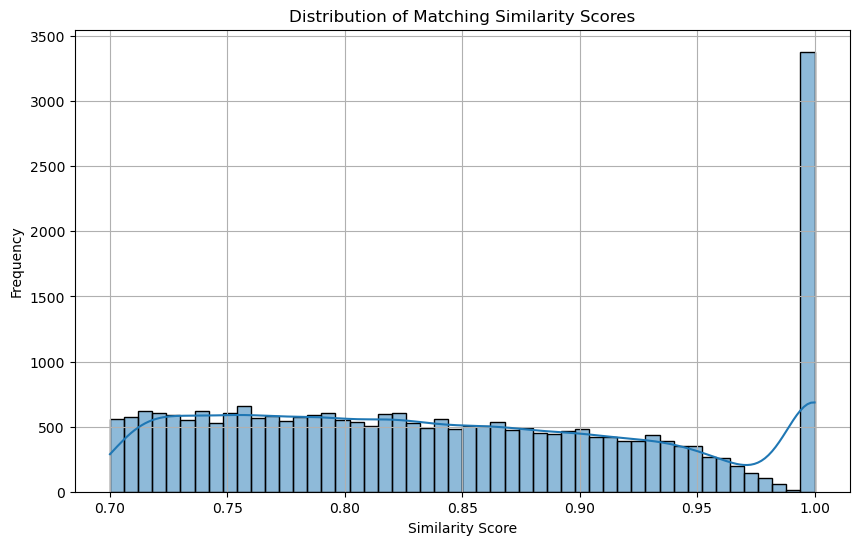


--- 相似度最低的10个匹配示例 ---
       company_code          glassdoor_company_name   gvkey  \
17199        929470  Integrated Information Network  165152   
3163           4618                A Finkl and Sons    9547   
14565        531007                 Saif Al Ghurair    6248   
21990       1371821         Astor Healthcare Center  141847   
22566       1373730          HST Software Solutions   32925   
21188       1369765                       Air Fayre  174025   
7842          12431          Hydro Dynamic Products   10011   
22325       1372939           Bostonia Public House    5215   
15894        645598            Wildnet Technologies  110329   
15895        645599            Wildnet Technologies  110329   

                wrds_matched_name  similarity  
17199                VYRE NETWORK    0.700013  
3163   SEAGRAM (JOSEPH E.) & SONS    0.700021  
14565               JENN-AIR CORP    0.700022  
21990      ODYSSEY HEALTHCARE INC    0.700023  
22566    HS GOVTECH SOLUTIONS INC    0.7000

In [ ]:
# --- 分析相似度分数分布 ---
print("\n--- 相似度分数描述性统计 ---")
print(df_mapping['similarity'].describe())

# --- 可视化分数分布 ---
plt.figure(figsize=(10, 6))
sns.histplot(df_mapping['similarity'], bins=50, kde=True)
plt.title('Distribution of Matching Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 打印一些低分数的例子，帮助我们理解低分意味着什么
print("\n--- 相似度最低的10个匹配 ---")
print(df_mapping.sort_values('similarity').head(10))

# 打印一些高分数的例子
print("\n--- 相似度最高的10个匹配 ---")
print(df_mapping.sort_values('similarity', ascending=False).head(10))

In [7]:
# --- 设定阈值并筛选 ---

# 根据你对分数分布和示例的分析，设定一个阈值
# 这是一个需要你根据实际情况调整的关键参数！
# 初始建议：
# - 0.95: 非常严格，结果最可靠，但样本损失最大。
# - 0.90: 比较严格，一个常用的权衡点。
# - 0.85: 相对宽松，可能会引入一些错误，需要抽样检查。
# 绝对不要使用低于0.8的阈值，除非你检查过。
SIMILARITY_THRESHOLD = 0.95

print(f"\n--- 应用相似度阈值: >= {SIMILARITY_THRESHOLD} ---")

# 筛选出高于阈值的匹配
df_high_confidence_mapping = df_mapping[df_mapping['similarity'] >= SIMILARITY_THRESHOLD].copy()

print(f"筛选前总匹配数: {len(df_mapping)}")
print(f"筛选后高置信度匹配数: {len(df_high_confidence_mapping)}")
sample_loss = len(df_mapping) - len(df_high_confidence_mapping)
sample_loss_pct = (sample_loss / len(df_mapping)) * 100 if len(df_mapping) > 0 else 0
print(f"因筛选而放弃的匹配数: {sample_loss} ({sample_loss_pct:.2f}%)")

# 保存筛选后的、更干净的映射文件
high_confidence_output_file = 'glassdoor_to_wrds_mapping_filtered.csv'
df_high_confidence_mapping.to_csv(high_confidence_output_file, index=False, encoding='utf-8-sig')

print(f"\n--- 成功！筛选后的高置信度映射文件已保存到: '{high_confidence_output_file}' ---")
print("在后续的阶段三中，请使用这个筛选过的文件进行合并。")


--- 应用相似度阈值: >= 0.95 ---
筛选前总匹配数: 26114
筛选后高置信度匹配数: 4533
因筛选而放弃的匹配数: 21581 (82.64%)

--- 成功！筛选后的高置信度映射文件已保存到: 'glassdoor_to_wrds_mapping_filtered.csv' ---
在后续的阶段三中，请使用这个筛选过的文件进行合并。


## 混合策略版

In [ ]:
import pandas as pd
from company_name_matcher import CompanyNameMatcher
from rapidfuzz import process, fuzz
import re
import os

print("--- 库导入成功 ---")

# --- 第1步：定义预处理函数 ---
# 解释：这是提升匹配质量最关键的一步。我们定义一个函数来标准化所有公司名称。
def clean_company_name(name):
    if not isinstance(name, str):
        return ""
    
    name = name.lower() # 1. 转为小写
    
    # 2. 移除常见的法律实体后缀
    # \b 是单词边界，确保我们只移除完整的单词
    suffixes = ['inc', 'llc', 'corp', 'corporation', 'ltd', 'limited', 'co', 'gmbh', 'ag', 'se', 'plc']
    for suffix in suffixes:
        name = re.sub(r'\b' + suffix + r'\b', '', name)
        
    # 3. 移除所有非字母数字的字符 (保留空格)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    
    # 4. 移除多余的空格
    name = ' '.join(name.split())
    
    return name.strip()

print("--- 清理函数定义完成 ---")


# --- 第2步：加载数据并应用清理 ---
phase1_output_file = 'firm_monthly_panel_data_revised.csv'
wrds_company_list_file = 'wrds_companies.csv'
mapping_output_file = 'glassdoor_to_wrds_mapping_hybrid.csv' # 新的输出文件名

# 加载数据
df_glassdoor = pd.read_csv(phase1_output_file)
df_wrds = pd.read_csv(wrds_company_list_file)

# 准备唯一的公司列表
df_glassdoor_unique = df_glassdoor[['company_code', 'company_name']].dropna(subset=['company_name']).drop_duplicates()
df_wrds_unique = df_wrds[['gvkey', 'conm']].dropna(subset=['conm']).drop_duplicates()

# 应用清理函数，创建新的'clean_name'列
print("--- 正在清理公司名称... ---")
df_glassdoor_unique['clean_name'] = df_glassdoor_unique['company_name'].apply(clean_company_name)
df_wrds_unique['clean_name'] = df_wrds_unique['conm'].apply(clean_company_name)

# 移除清理后为空的行
df_glassdoor_unique = df_glassdoor_unique[df_glassdoor_unique['clean_name'] != '']
df_wrds_unique = df_wrds_unique[df_wrds_unique['clean_name'] != '']

print("清理完成。")


# --- 第3步：执行分层匹配策略 ---
print("--- 开始执行分层匹配... ---")
matches = []
unmatched = df_glassdoor_unique.copy()

# === 第1层：精确匹配 ===
print("--- 第1层：执行精确匹配 ---")
exact_matches = pd.merge(
    unmatched,
    df_wrds_unique,
    on='clean_name',
    how='inner'
)
exact_matches['match_type'] = 'Exact'
exact_matches['similarity'] = 1.0
matches.append(exact_matches)
# 从待匹配列表中移除已匹配上的
unmatched = unmatched[~unmatched['company_code'].isin(exact_matches['company_code'])]
print(f"精确匹配找到 {len(exact_matches)} 个结果。剩余 {len(unmatched)} 个待匹配。")


# === 第2层：模糊字符串匹配 (RapidFuzz) ===
print("--- 第2层：执行高置信度模糊匹配 ---")
if not unmatched.empty:
    # 创建一个从WRDS清理后名称到原始信息的映射
    wrds_choices = df_wrds_unique['clean_name'].tolist()
    
    # 使用rapidfuzz的process.extract批量寻找最佳匹配
    # limit=1表示只返回最佳匹配项
    fuzzy_results = process.extract(
        unmatched['clean_name'].tolist(),
        wrds_choices,
        scorer=fuzz.WRatio, # WRatio对于不同长度和顺序的单词有很好的鲁棒性
        limit=1
    )
    
    # 处理结果
    fuzzy_matches_list = []
    for i, result in enumerate(fuzzy_results):
        if result and result[0][1] >= 90: # 设置一个高置信度阈值，例如90
            original_name = unmatched.iloc[i]
            matched_name, score, _ = result[0]
            
            fuzzy_matches_list.append({
                'company_code': original_name['company_code'],
                'clean_name': original_name['clean_name'],
                'matched_clean_name': matched_name,
                'similarity': score / 100.0,
                'match_type': 'Fuzzy'
            })
            
    if fuzzy_matches_list:
        df_fuzzy_matches = pd.DataFrame(fuzzy_matches_list)
        # 合并回WRDS的gvkey等信息
        df_fuzzy_matches = pd.merge(
            df_fuzzy_matches,
            df_wrds_unique,
            left_on='matched_clean_name',
            right_on='clean_name',
            suffixes=('_glassdoor', '_wrds')
        )
        matches.append(df_fuzzy_matches)
        unmatched = unmatched[~unmatched['company_code'].isin(df_fuzzy_matches['company_code'])]
        print(f"模糊匹配找到 {len(df_fuzzy_matches)} 个结果。剩余 {len(unmatched)} 个待匹配。")
    else:
        print("模糊匹配未找到高置信度结果。")


# === 第3層：語義匹配 (CompanyNameMatcher) ===
print("--- 第3层：对剩余的难例执行语义匹配 ---")
if not unmatched.empty:
    # 与之前一样，初始化并加载索引
    index_save_dir = "wrds_company_index_semantic"
    matcher = CompanyNameMatcher("paraphrase-multilingual-MiniLM-L12-v2")
    wrds_semantic_choices = df_wrds_unique['conm'].tolist()

    if not os.path.exists(index_save_dir):
        print("为语义匹配构建新索引...")
        matcher.build_index(wrds_semantic_choices, save_dir=index_save_dir)
        print("索引构建完成。")
    else:
        print("加载已有的语义匹配索引...")
        matcher.load_index(load_dir=index_save_dir)
        print("索引加载完成。")
        
    semantic_matches_list = []
    for _, row in unmatched.iterrows():
        # 注意：语义匹配使用原始名称，因为上下文可能很重要
        semantic_results = matcher.find_matches(row['company_name'], k=1, threshold=0.75, use_approx=True)
        if semantic_results:
            matched_name, score = semantic_results[0]
            semantic_matches_list.append({
                'company_code': row['company_code'],
                'conm': matched_name,
                'similarity': score,
                'match_type': 'Semantic'
            })
            
    if semantic_matches_list:
        df_semantic_matches = pd.DataFrame(semantic_matches_list)
        df_semantic_matches = pd.merge(df_semantic_matches, df_wrds_unique, on='conm')
        matches.append(df_semantic_matches)
        print(f"语义匹配找到 {len(df_semantic_matches)} 个结果。")


# --- 第4步：合并所有匹配结果并保存 ---
print("--- 第4步：合并所有匹配层级的结果... ---")
final_df = pd.concat(matches, ignore_index=True)

# 合并回原始的Glassdoor公司名
final_df = pd.merge(
    final_df,
    df_glassdoor_unique[['company_code', 'company_name']],
    on='company_code'
)

# 整理列顺序
final_df = final_df[[
    'company_code', 'company_name', 'gvkey', 'conm', 'similarity', 'match_type'
]]
final_df = final_df.rename(columns={'company_name': 'glassdoor_company_name', 'conm': 'wrds_matched_name'})

final_df.to_csv(mapping_output_file, index=False, encoding='utf-8-sig')

print(f"--- 成功！混合匹配完成，结果已保存到 '{mapping_output_file}' ---")
print(f"总共匹配到 {len(final_df)} / {len(df_glassdoor_unique)} 家公司。")
print(final_df['match_type'].value_counts())
print("\n")


# --- 第5步： smarter manual review ---
print("--- !!! 重要：下一步是进行更高效的人工校验 !!! ---")
print("建议操作：")
print(f"1. 打开输出文件 '{mapping_output_file}'。")
print("2. 重点关注 'match_type' 为 'Semantic' 的行，这些是置信度最低的。")
print("3. 其次检查 'match_type' 为 'Fuzzy' 且 'similarity' 较低（例如 90-95之间）的行。")
print("4. 'Exact' 类型的匹配通常是可靠的，可以快速浏览或忽略。")
print("这个流程将您的审查精力集中在最可能出错的地方，大大提高效率。")